In [1]:
import os
import ast

if "PATH_SET" not in locals():
    os.chdir("../..")
    PATH_SET = True

import torch

if "THREADS_SET" not in locals():
    try:
        os.environ["OMP_NUM_THREADS"] = "8"
        os.environ["MKL_NUM_THREADS"] = "8"

        torch.set_num_threads(8)
        torch.set_num_interop_threads(8)
        THREADS_SET = True
    except:
        pass

import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style

style.use(
    "https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle"
)

In [2]:
from helpers.geographic_setup import design_space_full, topo_data, grid_coords

from helpers.helper_functions import (
    SurfaceField_Distribution,
    concave_hull2D_prior_dist_constructor,
)


from helpers.likelihood import (
    DataLikelihoodAttenuation,
    DataLikelihood,
    logistic_picking_likelihood_tt,
)
from helpers.forward import TTLookup

from helpers.transparent_colormaps import blue_cmap

In [3]:
concave_hull2D_prior = concave_hull2D_prior_dist_constructor(
    design_space_full[..., :2],
    topo_data,
    buffer=20,
    depth=0,
    ratio=0.05,
    base_dist="sobol",
)

In [4]:
dx = 20

x = torch.from_numpy(topo_data["easting"].values).float()
y = torch.from_numpy(topo_data["northing"].values).float()
z = torch.from_numpy(topo_data.values).float()

x_posterior = torch.arange(x.min() + 100, x.max() - 200, dx)
y_posterior = torch.arange(y.min() + 100, y.max() - 200, dx)
z_posterior = torch.arange(topo_data.min().item() - 100, topo_data.max().item() + 1, dx)

In [5]:
X_posterior, Y_posterior, Z_posterior = torch.meshgrid(
    x_posterior, y_posterior, z_posterior, indexing="ij"
)

indices = torch.arange(Z_posterior.numel())
posterior_grid_full = torch.stack(
    [X_posterior.ravel(), Y_posterior.ravel(), Z_posterior.ravel(), indices], dim=-1
)
print(
    f"Memory usage: {posterior_grid_full.element_size() * posterior_grid_full.nelement() / 1e6:.2f} MB"
)

torch.save(posterior_grid_full, "data/priors/full_posterior_grid.pt")

Memory usage: 12.78 MB


In [6]:
file_name_m_prior = "data/priors/surface_displacement_prior.pt"

model_prior_sd = SurfaceField_Distribution(
    distibution=torch.load(file_name_m_prior, weights_only=False).forward(),
    topo_data=topo_data,
    depth=300,
)

N_test = 100
torch.manual_seed(0)
test_events = model_prior_sd.sample((N_test,))

In [7]:
# Monte Carlo estimate of entropy: H[p] ≈ -1/N ∑ log p(x_i), x_i ~ p
with torch.no_grad():
    samples = model_prior_sd.sample((int(1e5),))
    log_probs = model_prior_sd.log_prob(samples, fast_eval=False)
    entropy_mc = -log_probs.mean().item()
print(f"Monte Carlo estimated entropy: {entropy_mc:.4f} nats")

Monte Carlo estimated entropy: 19.9830 nats


  0%|          | 0/100 [00:00<?, ?it/s]

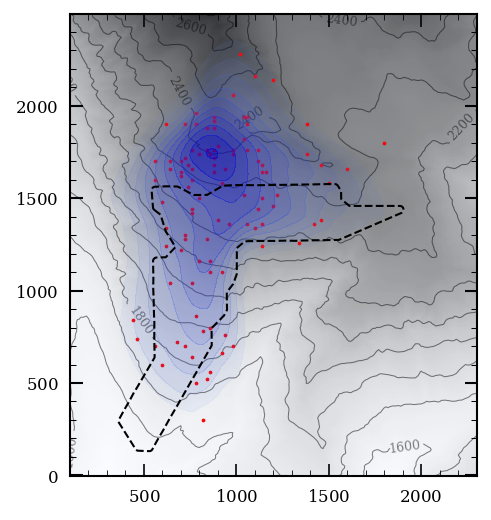

In [8]:
prior_sd = (
    model_prior_sd.log_prob(grid_coords.squeeze(), fast_eval=False)
    .exp()
    .detach()
    .numpy()
    .reshape(topo_data.shape)
)

# Generate heterogeneous displacement predictions for the test events
test_events_tmp = []
for event in tqdm(test_events):
    # Find closest point in posterior grid
    distances = torch.sum((posterior_grid_full[:, :3] - event) ** 2, dim=1)
    closest_idx = torch.argmin(distances)
    closest_point = posterior_grid_full[closest_idx]
    test_events_tmp.append(closest_point)
# Stack results
test_events = torch.stack(test_events_tmp)


# Plot a few examples to verify
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(test_events[:, 0], test_events[:, 1], c="r", s=1)

ax.contourf(
    topo_data.easting,
    topo_data.northing,
    prior_sd.T,
    cmap=blue_cmap,
    levels=10,
    zorder=2,
)

ax.pcolormesh(
    topo_data.easting,
    topo_data.northing,
    topo_data.values.T,
    rasterized=True,
    cmap="Greys",
    zorder=-20,
    alpha=0.8,
)


ax.pc = ax.contour(
    topo_data.easting,
    topo_data.northing,
    topo_data.values.T,
    colors="k",
    zorder=-10,
    levels=np.arange(0, 3000, 100),
    linewidths=0.5,
    alpha=0.5,
)

ax.cl = ax.clabel(
    ax.pc,
    levels=np.arange(0, 3000, 200),
    inline=True,
    fontsize=6,
    fmt="%1.0f",
    colors="k",
    use_clabeltext=True,
)

ax.plot(
    *np.array(concave_hull2D_prior.shapley_poly.exterior.coords.xy),
    color="k",
    linewidth=1.0,
    linestyle="--",
    zorder=2,
    alpha=1.0,
    label="accesible area",
)

ax.set_aspect("equal")
ax.set_xlim(100, 2300)

ax.set_aspect("equal")
plt.show()

In [9]:
forward_function_heterogenous = TTLookup(
    posterior_grid_full,
    design_space_full,
    torch.load("data/data_lookup/heterogeneous_full_posterior.pt"),
)

picking_likelihood = logistic_picking_likelihood_tt(
    b=-30,
    c=0.35,
)


data_likelihood = DataLikelihoodAttenuation(
    forward_function=forward_function_heterogenous,
    dependence_distance=150,
    vel_sigma=0.05,
    picking_likelihood=picking_likelihood,
    tt_obs_std=0.01,
)

data_likelihood_post = DataLikelihood(
    forward_function=forward_function_heterogenous,
    dependence_distance=150,
    vel_sigma=0.05,
    tt_obs_std=0.01,
)

In [10]:
design_df = pd.read_csv("generate_designs/data/design_data.csv")

design_df = design_df[design_df["study_area"] == "full"]
# Reset DataFrame indices to avoid potential issues
design_df = design_df.reset_index(drop=True)

# Check for missing or problematic columns
required_columns = [
    "study_area",
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "drop_mean",
    "drop_gradient",
    "optimisation",
    "EIG_method",
    "EIG_N",
    "design",
]
missing_columns = [col for col in required_columns if col not in design_df.columns]
if missing_columns:
    print(f"Warning: Missing columns in design_df: {missing_columns}")

# Convert design column from string to tensor if needed
if "design" in design_df.columns and isinstance(design_df["design"].iloc[0], str):
    design_df["design"] = design_df["design"].apply(
        lambda x: torch.tensor(ast.literal_eval(x))
    )

print(f"Number of designs: {len(design_df)}")
print(f"Number of events : {len(test_events)}")

Number of designs: 4437
Number of events : 100


In [11]:
with torch.no_grad():
    log_p_prior_original = model_prior_sd.log_prob(posterior_grid_full, fast_eval=False)
    log_p_prior_original = log_p_prior_original.reshape(X_posterior.shape)

p_prior = log_p_prior_original.exp()
p_prior = p_prior / torch.nansum(
    p_prior
)  # for some reason prior is not normalized, do it here

prior_mask = log_p_prior_original.isfinite()

log_p_prior = p_prior.log()
log_p_prior[~prior_mask] = torch.nan

In [12]:
# Compute grid spacings
dx_val = float(dx)
dy_val = float(dx)
dz_val = float(dx)

grid_volume = dx_val * dy_val * dz_val
entropy_correction = np.log(grid_volume)

In [13]:
import os

summary_statistics_file = "benchmark_designs/full/data/summary_statistics.csv"

if os.path.exists(summary_statistics_file):
    summary_statistics = pd.read_csv(summary_statistics_file)
    print(f"Loaded summary statistics from {summary_statistics_file}")
else:
    print(f"Calculating summary statistics and saving to {summary_statistics_file}")

    print(
        f"Memory usage: {log_p_prior.element_size() * log_p_prior.nelement() / 1e6:.2f} MB"
    )
    print(f"Prior mask ratio: {prior_mask.sum().item() / prior_mask.nelement():.2f}")

    summary_statistics = pd.DataFrame(
        columns=[
            "study_area", "model_prior", "velocity_model", "vel_sigma", "noise_correlation", "drop_mean", "drop_gradient", "optimisation", "EIG_method", "EIG_N", "N_rec", "design", "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z", "distance_mean", "distance_map", "p_posterior", "posterior_entropy", "posterior_information", "prior_entropy", "prior_information", "event", "event_index",
        ]
    )

    def is_scenario_in_design_data(design_data, scen, N_rec, event_index):
        design_data = pd.DataFrame(design_data, columns=summary_statistics.columns)

        out = (
            (design_data["study_area"] == scen["study_area"])
            & (design_data["model_prior"] == scen["model_prior"])
            & (design_data["velocity_model"] == scen["velocity_model"])
            & (design_data["vel_sigma"] == scen["vel_sigma"])
            & (design_data["noise_correlation"] == scen["noise_correlation"])
            & (design_data["drop_mean"] == scen["drop_mean"])
            & (design_data["drop_gradient"] == scen["drop_gradient"])
            & (design_data["optimisation"] == scen["optimisation"])
            & (design_data["EIG_method"] == scen["EIG_method"])
            & (design_data["EIG_N"] == scen["EIG_N"])
            & (design_data["N_rec"] == N_rec)
            & (design_data["event_index"] == event_index)
        ).any()
        return out

    for d_i, scen in tqdm(design_df.iterrows(), total=len(design_df)):
        posterior_file = f"benchmark_designs/full/data/scenario_{scen['study_area']}_{scen['model_prior']}_{scen['velocity_model']}_{scen['vel_sigma']:.3f}_{scen['noise_correlation']:.1f}_{scen['drop_mean']:.1f}_{scen['drop_gradient']:.1f}_{scen['optimisation']}_{scen['EIG_method']}_{scen['EIG_N']}.csv"
        design = scen["design"]
        receiver_indices = design[..., -1].int().tolist()

        if os.path.exists(posterior_file):
            try:
                posterior_stat_df = pd.read_csv(posterior_file)
            except Exception as e:
                print(f"Error reading {posterior_file}, creating new DataFrame.")
                raise e
        else:
            posterior_stat_df = pd.DataFrame(columns=list(summary_statistics.columns))
            posterior_stat_df.to_csv(posterior_file, index=False)

        torch.manual_seed(0)

        for e_i, event in tqdm(
            enumerate(test_events),
            total=len(test_events),
            desc=f"Scenario {d_i}",
            disable=True,
            leave=False,
        ):
            if is_scenario_in_design_data(
                posterior_stat_df, scen, len(receiver_indices), e_i
            ):
                pass
            else:
                dl = data_likelihood(
                    torch.tensor([0.5]).unsqueeze(0), event.unsqueeze(0), design
                )

                tt_obs = dl.sample().squeeze(0)
                tt_obs_cov = dl.scale_tril

                std_diag = torch.sqrt(torch.diagonal(tt_obs_cov.squeeze(0)))
                mask = std_diag < 0.5

                design_tmp = design[mask]
                tt_obs = tt_obs[mask]
                tt_obs_cov = tt_obs_cov[..., mask, :][..., mask]

                if len(tt_obs) < 1:
                    log_p_posterior = log_p_prior
                else:
                    log_p_likelihood = data_likelihood_post(
                        posterior_grid_full[prior_mask.flatten()],
                        design_tmp,
                        posterior_cov=tt_obs_cov,
                    ).log_prob(tt_obs)

                    log_p_unnormalised_posterior = (
                        log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
                    )
                    log_p_evidence = torch.logsumexp(
                        log_p_unnormalised_posterior, dim=0
                    )

                    log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
                    log_p_posterior[prior_mask.flatten()] = (
                        log_p_unnormalised_posterior - log_p_evidence
                    )
                    log_p_posterior = log_p_posterior.reshape(X_posterior.shape)

                p_prior = log_p_prior.exp()
                p_posterior = log_p_posterior.exp()

                p_prior = torch.nan_to_num(p_prior, nan=0.0)
                p_posterior = torch.nan_to_num(p_posterior, nan=0.0)

                event_x, event_y, event_z = event[:3].tolist()

                mean_x = (X_posterior * p_posterior).sum() / p_posterior.sum()
                mean_y = (Y_posterior * p_posterior).sum() / p_posterior.sum()
                mean_z = (Z_posterior * p_posterior).sum() / p_posterior.sum()

                std_x = torch.sqrt(
                    ((X_posterior - mean_x) ** 2 * p_posterior).sum()
                    / p_posterior.sum()
                )
                std_y = torch.sqrt(
                    ((Y_posterior - mean_y) ** 2 * p_posterior).sum()
                    / p_posterior.sum()
                )
                std_z = torch.sqrt(
                    ((Z_posterior - mean_z) ** 2 * p_posterior).sum()
                    / p_posterior.sum()
                )

                squared_dist_mean_x = (mean_x - event[0]) ** 2
                squared_dist_mean_y = (mean_y - event[1]) ** 2
                squared_dist_mean_z = (mean_z - event[2]) ** 2
                distance_mean = torch.sqrt(
                    squared_dist_mean_x + squared_dist_mean_y + squared_dist_mean_z
                )

                max_idx = torch.argmax(p_posterior.flatten())
                map_x = X_posterior.flatten()[max_idx]
                map_y = Y_posterior.flatten()[max_idx]
                map_z = Z_posterior.flatten()[max_idx]

                squared_dist_map_x = (map_x - event[0]) ** 2
                squared_dist_map_y = (map_y - event[1]) ** 2
                squared_dist_map_z = (map_z - event[2]) ** 2
                distance_map = torch.sqrt(
                    squared_dist_map_x + squared_dist_map_y + squared_dist_map_z
                )

                interp = RegularGridInterpolator(
                    (x_posterior, y_posterior, z_posterior),
                    p_posterior.numpy(),
                    bounds_error=False,
                    fill_value=0.0,
                )
                post_p = interp(event[:3].numpy()).item()

                entropy_terms = torch.log(p_posterior) * p_posterior
                post_entropy = -torch.nansum(entropy_terms)
                post_info = -post_entropy

                entropy_terms_prior = torch.log(p_prior) * p_prior
                prior_entropy = -torch.nansum(entropy_terms_prior)
                prior_info = -prior_entropy

                posterior_stat_df.loc[len(posterior_stat_df)] = [
                    scen["study_area"],
                    scen["model_prior"],
                    scen["velocity_model"],
                    scen["vel_sigma"],
                    scen["noise_correlation"],
                    scen["drop_mean"],
                    scen["drop_gradient"],
                    scen["optimisation"],
                    scen["EIG_method"],
                    scen["EIG_N"],
                    len(receiver_indices),
                    design.tolist(),
                    mean_x.item(),
                    mean_y.item(),
                    mean_z.item(),
                    std_x.item(),
                    std_y.item(),
                    std_z.item(),
                    distance_mean.item(),
                    distance_map.item(),
                    post_p,
                    post_entropy.item(),
                    post_info.item(),
                    prior_entropy.item(),
                    prior_info.item(),
                    event,
                    e_i,
                ]

                posterior_stat_df.to_csv(posterior_file, index=False)

    import glob

    all_dfs = []
    data_dir = "benchmark_designs/full/data"
    pattern = os.path.join(data_dir, "scenario_*.csv")
    posterior_files = glob.glob(pattern)

    for posterior_stat_file in posterior_files:
        if os.path.exists(posterior_stat_file):
            try:
                df = pd.read_csv(posterior_stat_file)
                all_dfs.append(df)
            except Exception as e:
                print(f"Error processing {posterior_stat_file}: {e}")

    # made a small typo in the design generation, so we need to fix the drop_gradient value
    # this will not change any of the results
    summary_statistics.to_csv(
        "benchmark_designs/full/data/summary_statistics.csv", index=False
    )
    
    
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        summary_statistics = combined_df

        summary_statistics["posterior_entropy"] += entropy_correction
        summary_statistics["prior_entropy"] += entropy_correction

        summary_statistics["posterior_information"] -= entropy_correction
        summary_statistics["prior_information"] -= entropy_correction

        summary_statistics.loc[summary_statistics["drop_gradient"] == -13.0, "drop_gradient"] = -15.0

        summary_statistics.to_csv(summary_statistics_file, index=False)
        print(
            f"Combined {len(all_dfs)} posterior statistic files into summary_statistics.csv"
        )
        print(f"Total number of entries: {len(summary_statistics)}")
    else:
        print("No posterior statistic files found to process.")
    


Calculating summary statistics and saving to benchmark_designs/full/data/summary_statistics.csv
Memory usage: 3.19 MB
Prior mask ratio: 0.22


  0%|          | 0/4437 [00:00<?, ?it/s]

Combined 286 posterior statistic files into summary_statistics.csv
Total number of entries: 431701


In [14]:
import os

random_stats_file = "benchmark_designs/full/data/random_stats.csv"
sobol_stats_file = "benchmark_designs/full/data/sobol_stats.csv"


def calc_random_stats_3d(
    design_sampler,
    design_space,
    N_random=100,
    N_rec_min=2,
    N_rec_max=10,
    method_name="random",
):
    stats = []
    torch.manual_seed(0)
    for N_rec in tqdm(
        range(N_rec_min, N_rec_max + 1), desc=f"Calculating {method_name} stats"
    ):
        for i in tqdm(range(N_random), desc=f"N_rec={N_rec}", leave=False, position=1):
            # Sample random design
            design = design_sampler(N_rec)
            # Find closest in design_space for each design point
            indices = torch.cdist(
                design.unsqueeze(0)[..., :3], design_space_full[..., :3]
            ).argmin(dim=-1)
            design_selected = design_space_full[indices].squeeze(0)
            # For each event, get tt_obs
            for e_i, event in enumerate(test_events):
                dl = data_likelihood(
                    torch.tensor([0.5]).unsqueeze(0),
                    event.unsqueeze(0),
                    design_selected,
                )
                tt_obs = dl.sample().squeeze(0)
                tt_obs_cov = dl.scale_tril

                std_diag = torch.sqrt(torch.diagonal(tt_obs_cov.squeeze(0)))
                mask = std_diag < 0.5
                design_tmp = design_selected[mask]
                tt_obs_valid = tt_obs[mask]
                tt_obs_cov_valid = tt_obs_cov[..., mask, :][..., mask]

                if len(tt_obs_valid) < 1:
                    log_p_posterior = log_p_prior
                else:
                    log_p_likelihood = data_likelihood_post(
                        posterior_grid_full[prior_mask.flatten()],
                        design_tmp,
                        posterior_cov=tt_obs_cov_valid,
                    ).log_prob(tt_obs_valid)
                    log_p_unnormalised_posterior = (
                        log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
                    )
                    log_p_evidence = torch.logsumexp(
                        log_p_unnormalised_posterior, dim=0
                    )
                    log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
                    log_p_posterior[prior_mask.flatten()] = (
                        log_p_unnormalised_posterior - log_p_evidence
                    )
                    log_p_posterior = log_p_posterior.reshape(X_posterior.shape)

                p_prior = log_p_prior.exp()
                p_posterior = log_p_posterior.exp()
                p_prior = torch.nan_to_num(p_prior, nan=0.0)
                p_posterior = torch.nan_to_num(p_posterior, nan=0.0)

                mean_x = (X_posterior * p_posterior).sum() / p_posterior.sum()
                mean_y = (Y_posterior * p_posterior).sum() / p_posterior.sum()
                mean_z = (Z_posterior * p_posterior).sum() / p_posterior.sum()
                std_x = torch.sqrt(
                    ((X_posterior - mean_x) ** 2 * p_posterior).sum()
                    / p_posterior.sum()
                )
                std_y = torch.sqrt(
                    ((Y_posterior - mean_y) ** 2 * p_posterior).sum()
                    / p_posterior.sum()
                )
                std_z = torch.sqrt(
                    ((Z_posterior - mean_z) ** 2 * p_posterior).sum()
                    / p_posterior.sum()
                )

                squared_dist_mean_x = (mean_x - event[0]) ** 2
                squared_dist_mean_y = (mean_y - event[1]) ** 2
                squared_dist_mean_z = (mean_z - event[2]) ** 2
                distance_mean = torch.sqrt(
                    squared_dist_mean_x + squared_dist_mean_y + squared_dist_mean_z
                )

                max_idx = torch.argmax(p_posterior.flatten())
                map_x = X_posterior.flatten()[max_idx]
                map_y = Y_posterior.flatten()[max_idx]
                map_z = Z_posterior.flatten()[max_idx]
                squared_dist_map_x = (map_x - event[0]) ** 2
                squared_dist_map_y = (map_y - event[1]) ** 2
                squared_dist_map_z = (map_z - event[2]) ** 2
                distance_map = torch.sqrt(
                    squared_dist_map_x + squared_dist_map_y + squared_dist_map_z
                )

                interp = RegularGridInterpolator(
                    (x_posterior, y_posterior, z_posterior),
                    p_posterior.numpy(),
                    bounds_error=False,
                    fill_value=0.0,
                )
                post_p = interp(event[:3].numpy()).item()

                entropy_terms = torch.log(p_posterior) * p_posterior
                post_entropy = -torch.nansum(entropy_terms) + entropy_correction
                post_info = -post_entropy
                entropy_terms_prior = torch.log(p_prior) * p_prior
                prior_entropy = -torch.nansum(entropy_terms_prior) + entropy_correction
                prior_info = -prior_entropy

                stats.append(
                    dict(
                        method=method_name,
                        N_rec=N_rec,
                        design=design_selected.tolist(),
                        mean_x=mean_x.item(),
                        mean_y=mean_y.item(),
                        mean_z=mean_z.item(),
                        std_x=std_x.item(),
                        std_y=std_y.item(),
                        std_z=std_z.item(),
                        distance_mean=distance_mean.item(),
                        distance_map=distance_map.item(),
                        p_posterior=post_p,
                        posterior_entropy=post_entropy.item(),
                        posterior_information=post_info.item(),
                        prior_entropy=prior_entropy.item(),
                        prior_information=prior_info.item(),
                        event=event.tolist(),
                        event_index=e_i,
                    )
                )
    return pd.DataFrame(stats)


# Random design stats
if os.path.exists(random_stats_file):
    random_stats_df = pd.read_csv(random_stats_file)
else:

    def uniform_sampler(N_rec):
        idx = torch.randint(len(design_space_full), (N_rec,))
        return design_space_full[idx]

    random_stats_df = calc_random_stats_3d(
        uniform_sampler,
        design_space_full,
        N_random=100,
        N_rec_min=2,
        N_rec_max=15,
        method_name="random",
    )
    random_stats_df.to_csv(random_stats_file, index=False)

# Sobol design stats
if os.path.exists(sobol_stats_file):
    sobol_stats_df = pd.read_csv(sobol_stats_file)
else:

    def sobol_sampler(N_rec):
        design_space_dist = concave_hull2D_prior_dist_constructor(
            design_space_full[..., :3],
            topo_data,
            base_dist="sobol",
            buffer=20,
            depth=0,
            ratio=0.05,
        )
        return design_space_dist.sample(N_rec).float()

    sobol_stats_df = calc_random_stats_3d(
        sobol_sampler,
        design_space_full,
        N_random=100,
        N_rec_min=2,
        N_rec_max=15,
        method_name="sobol",
    )
    sobol_stats_df.to_csv(sobol_stats_file, index=False)

In [15]:
# Add design_index to random_stats_df and sobol_stats_df
# design_index is the index within each (N_rec, event_index) group


def add_design_index(df):
    # If already present, do not add again
    if "design_index" in df.columns:
        return df
    # Assign design_index within each (N_rec, event_index) group
    df = df.copy()
    df["design_index"] = df.groupby(["N_rec", "event_index"]).cumcount()
    return df


random_stats_df = add_design_index(random_stats_df)
sobol_stats_df = add_design_index(sobol_stats_df)

# Get Combined Statistics

In [16]:
scen_columns = [
    "study_area",
    "model_prior",
    "velocity_model",
    "vel_sigma",
    "noise_correlation",
    "drop_mean",
    "drop_gradient",
    "optimisation",
    "EIG_method",
    "EIG_N",
]

stat_columns = [
    "mean_x",
    "mean_y",
    "mean_z",
    "std_x",
    "std_y",
    "std_z",
    "distance_mean",
    "distance_map",
    "p_posterior",
    "posterior_entropy",
    "posterior_information",
    "prior_entropy",
    "prior_information",
]

In [17]:
# N_rec_min = random_stats_df["N_rec"].min()
N_rec_min = 2
N_rec_max = 5  # careful if this is above EIG_N > 1000 not working anymore

In [18]:
import numpy as np

# Filter for N_rec in the desired range
df_filtered = summary_statistics[
    (summary_statistics["N_rec"] >= N_rec_min)
    & (summary_statistics["N_rec"] <= N_rec_max)
]
df_filtered = df_filtered.drop(columns="design")
# First, group by scenario columns and N_rec, then average over events
grouped = (
    df_filtered.groupby(scen_columns + ["N_rec"])[stat_columns].mean().reset_index()
)

# Add EIG values from design_df to grouped by matching scenario columns and N_rec
grouped = grouped.copy()
grouped["EIG"] = np.nan

for idx, row in grouped.iterrows():
    # Find matching scenario in design_df, including N_rec
    mask = True
    for col in scen_columns + ["N_rec"]:
        mask &= design_df[col] == row[col]
    df_match = design_df[mask]

    if not df_match.empty:
        eig_value = df_match.iloc[0]["EIG_ref"]
        grouped.at[idx, "EIG"] = eig_value

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(grouped.head(100))

agg_stats = (
    grouped.groupby(scen_columns)
    .agg(
        {
            "EIG": "mean",
            "mean_x": "mean",
            "mean_y": "mean",
            "mean_z": "mean",
            "std_x": "mean",
            "std_y": "mean",
            "std_z": "mean",
            "distance_mean": "mean",
            "distance_map": "mean",
            "p_posterior": "mean",
            "posterior_entropy": "mean",
            "posterior_information": "mean",
            "prior_entropy": "mean",
            "prior_information": "mean",
        }
    )
    .reset_index()
)

agg_stats = agg_stats[
    (
        ((agg_stats["EIG_method"] == "DN") & (agg_stats["drop_mean"] == 0.0))
        | (agg_stats["EIG_method"] == "NMC")
    )
]

print(f"Number of aggregated scenarios: {len(agg_stats)}")

Number of aggregated scenarios: 258


In [19]:
# First, group by N_rec and event_index, then average over events for each design_index
random_grouped = (
    random_stats_df[
        (random_stats_df["N_rec"] >= N_rec_min)
        & (random_stats_df["N_rec"] <= N_rec_max)
    ]
    .groupby(
        [
            "N_rec",
            "design_index",
        ]
    )[stat_columns]
    .mean()
    .groupby(["design_index"])[stat_columns]
    .mean()
    .reset_index()
)

sobol_grouped = (
    sobol_stats_df[
        (sobol_stats_df["N_rec"] >= N_rec_min) & (sobol_stats_df["N_rec"] <= N_rec_max)
    ]
    .groupby(
        [
            "N_rec",
            "design_index",
        ]
    )[stat_columns]
    .mean()
    .groupby(["design_index"])[stat_columns]
    .mean()
    .reset_index()
)

# Add EIG values from design_df to random_grouped and sobol_grouped

import numpy as np


def add_eig_to_grouped(grouped_df, method, design_df):
    # Filter design_df for the correct method
    df = design_df[
        (design_df["optimisation"] == method)
        & (design_df["velocity_model"] == "gradient")
        & (design_df["drop_mean"] == 0.35)
    ].copy()
    # Convert EIG_candidates column to arrays

    eig_arrays = np.array(
        [np.array(ast.literal_eval(eig)) for eig in df["EIG_candidates"].values]
    )
    eig_arrays = eig_arrays.mean(axis=0)  # Average over samples

    # If there are more EIG candidates than designs, take only the first N
    N = len(grouped_df)
    eig_arrays = eig_arrays[:N]

    grouped_df = grouped_df.copy()
    grouped_df["EIG"] = eig_arrays
    return grouped_df


random_grouped = add_eig_to_grouped(random_grouped, "random", design_df)
sobol_grouped = add_eig_to_grouped(sobol_grouped, "sobol", design_df)

# Display or use as needed
print("Random stats (aggregated):")
print(random_grouped.shape)

print("Sobol stats (aggregated):")
print(sobol_grouped.shape)

Random stats (aggregated):
(100, 15)
Sobol stats (aggregated):
(100, 15)


In [20]:
scen_columns

['study_area',
 'model_prior',
 'velocity_model',
 'vel_sigma',
 'noise_correlation',
 'drop_mean',
 'drop_gradient',
 'optimisation',
 'EIG_method',
 'EIG_N']

In [21]:
from matplotlib.lines import Line2D
import pandas as pd

def plot_combinations(
    ax,
    data,
    x_quantity,
    y_quantity,
    param1,
    param2=None,
    color_dict=None,
    marker_dict=None,
    random_grouped=random_grouped,
    sobol_grouped=sobol_grouped,
    background_alpha=0.35,
    title=None,
    attenuation=None,
    set_defaults=True,
    select_matching=False
):
    """
    Filter data to ensure unbiased comparison of param1 and param2 performance.
    Retain only rows where all unique combinations of other parameters (excluding param1 and param2)
    have results for all combinations of param1 and param2.
    """
    
    data_original = data.copy()
    
    if set_defaults:
        if 'model_prior' not in [param1, param2]:
            data = data[data['model_prior'] == 'displacement']
        if 'EIG_method' not in [param1, param2]:
            data = data[data['EIG_method'] == 'NMC']
        if 'EIG_N' not in [param1, param2]:
            data = data[data['EIG_N'] == 1000]
        if 'optimisation' not in [param1, param2]:
            data = data[data['optimisation'].isin(['iterative', 'genetic'])]
        if 'drop_mean' not in [param1, param2]:
            data = data[
                (data['drop_mean'] == 0.35) | (data['drop_mean'] == 0.0)
            ]
        if 'drop_gradient' not in [param1, param2]:
            data = data[
                (data['drop_gradient'] == 0.0) | (data['drop_gradient'] == -15.0)
            ]
        if 'velocity_model' not in [param1, param2]:
            data = data[data['velocity_model'] == 'gradient']
        if 'vel_sigma' not in [param1, param2]:
            data = data[
                ((data['velocity_model'] == 'heterogeneous') & (data['vel_sigma'] == 0.01))
                | ((data['velocity_model'].isin(['gradient', 'homogeneous'])) & (data['vel_sigma'] == 0.05))
            ]
        if 'noise_correlation' not in [param1, param2]:
            data = data[data['noise_correlation'] == 100.0]   
    
    # Identify columns to exclude param1 and param2
    param_cols = [param1] + ([param2] if param2 and param1 != param2 else [])
    other_cols = [c for c in ['model_prior', 'velocity_model', 'vel_sigma', 'noise_correlation',
                              'drop_mean', 'drop_gradient', 'optimisation', 'EIG_method', 'EIG_N']
                  if c not in param_cols]

    if attenuation is not None:
        if attenuation:
            data = data[data['drop_mean'] > 0.0]
        else:
            data = data[data['drop_mean'] == 0.0]

    if select_matching:
        # Group by other_cols and param1/param2 combinations
        grouped = data.groupby(other_cols)

        # for g in grouped.groups:
        #     group = grouped.get_group(g)
        #     display(group)

        # Filter groups to keep only scenarios that exist in all combinations of param1 and param2
        # Filter for groups where all param1/param2 combinations are present
        valid_indices = []
        for name, group in grouped:
            # Get all unique param combinations in the dataset
            param_combinations = data[param_cols].drop_duplicates()
            # Count how many combinations are in this group
            group_combinations = group[param_cols].drop_duplicates()
            # If all combinations are present in this group, keep it
            if len(group_combinations) == len(param_combinations):
                valid_indices.extend(group.index.tolist())
            
        # Convert to pandas Index
        valid_indices = pd.Index(valid_indices)

        # Filter the data to keep only valid rows
        data = data.loc[valid_indices]

    quantity_labels = {
        'distance_mean': 'Mean Distance Error (m)',
        'distance_map': 'MAP Distance Error (m)',
        'posterior_entropy': 'Posterior Entropy (nats)',
        'EIG': 'Expected Information Gain (nats)',
    }
    
    legend_label_map = {
        'EIG_method': 'EIG Method',
        'EIG_N': r'$N_\text{EIG}$',
        'velocity_model': 'Vel. Model',
        'drop_mean': r'Drop Mean',
        'drop_gradient': r'Drop Gradient',
        'optimisation': 'Optimisation',
        'vel_sigma': r'$\sigma_\text{vel}$',
        'noise_correlation': r'Noise Cor.',
        'model_prior': 'Model Prior',
    }
    
    title_label_map = {
        'EIG_method': 'EIG Method',
        'EIG_N': r'Number of Samples $N_\text{EIG}$',
        'velocity_model': 'Velocity Model',
        'drop_mean': r'Drop Mean',
        'drop_gradient': r'Drop Gradient',
        'optimisation': 'Optimisation',
        'vel_sigma': r'Velocity Uncertainty $\sigma_\text{vel}$',
        'noise_correlation': r'Noise Correlation',
        'model_prior': 'Model Prior',
    }

    size_map = {
        'p' : 30*1.5,  # p for pentagon
        's' : 25*1.5,  # s for square
        '^' : 35*1.5,  # ^ for triangle
        'o' : 20*1.5,  # o for circle
        'X' : 20*1.5,  # x for cross
        'P' : 20*1.5,  # P for plus
    }
    
    # Plot background (random and sobol)
    if random_grouped is not None:
        ax.scatter(
            random_grouped[x_quantity], random_grouped[y_quantity],
            edgecolors='none', color='grey', alpha=background_alpha, s=15, label='_nolegend_', zorder=1
        )
    if sobol_grouped is not None:
        ax.scatter(
            sobol_grouped[x_quantity], sobol_grouped[y_quantity],
            edgecolors='none', color='tab:olive', alpha=background_alpha, s=15, label='_nolegend_', zorder=1
        )

    # Plot main points
    for _, row in data.iterrows():
        marker = marker_dict.get(row[param1], 'o') if marker_dict else 'o'
        marker_size = size_map.get(marker, 100)  # Default size if not found in size_map
        color = color_dict.get(row[param2], 'gray') if (color_dict and param2) else 'gray'
        ax.scatter(
            row[x_quantity], row[y_quantity],
            marker=marker, facecolor=color, edgecolor='black', linewidth=1.0, alpha=1.0, s=marker_size, zorder=10,
        )

    ax.set_xlabel(quantity_labels.get(x_quantity, x_quantity) if quantity_labels else x_quantity, fontsize=10)
    ax.set_ylabel(quantity_labels.get(y_quantity, y_quantity) if quantity_labels else y_quantity, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    if title:
        # If title is a tuple/list of (param1, param2), map both to their labels
        if isinstance(title, (tuple, list)) and len(title) == 2:
            label1 = title_label_map.get(title[0], str(title[0])) if title_label_map else str(title[0])
            label2 = title_label_map.get(title[1], str(title[1])) if title_label_map else str(title[1])
            ax.set_title(f"{label1} vs {label2}", fontsize=11)
        # If title is a string with ' vs ', split and map both
        elif isinstance(title, str) and ' vs ' in title:
            t1, t2 = title.split(' vs ', 1)
            label1 = title_label_map.get(t1, t1) if title_label_map else t1
            label2 = title_label_map.get(t2, t2) if title_label_map else t2
            ax.set_title(f"{label1} vs {label2}", fontsize=11)
        # Otherwise, map as usual
        else:
            label = title_label_map.get(title, title) if title_label_map else title
            ax.set_title(label, fontsize=11)

    # Custom legend: show marker and color explanations separately
    legend_elements = []

    # Markers for param1
    # If param1 and param2 are the same, combine marker and color in one legend entry
    if param1 == param2 and marker_dict and color_dict:
        for key in marker_dict:
            marker = marker_dict[key]
            color = color_dict.get(key, 'gray')
            label = legend_label_map.get(param1, param1)
            # Special label for attenuation
            if (
                param1 in ['drop_mean', 'drop_gradient']
                and isinstance(marker_dict, dict)
                and len(marker_dict) == 2
                and (isinstance(key, (int, float)) and key > 0)
            ):
                legend_label = 'Attenuation'
            elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                legend_label = 'No Attenuation'
            else:
                legend_label = f'{label} = {key}'
            legend_elements.append(
                Line2D([0], [0], marker=marker, color='w', label=legend_label,
                    markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
            )
    else:
        # Markers for param1
        if marker_dict:
            for key, marker in marker_dict.items():
                label = legend_label_map.get(param1, param1)
                # Special label for attenuation
                if (
                    param1 in ['drop_mean', 'drop_gradient']
                    and isinstance(marker_dict, dict)
                    and len(marker_dict) == 2
                    and (isinstance(key, (int, float)) and key > 0)
                ):
                    legend_label = 'Attenuation'
                elif param1 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                    legend_label = 'No Attenuation'
                else:
                    legend_label = f'{label} = {key}'
                legend_elements.append(
                    Line2D([0], [0], marker=marker, color='w', label=legend_label,
                        markeredgewidth=1.0, markerfacecolor='gray', markeredgecolor='black', markersize=7.5, linestyle='None')
                )

        # Colors for param2
        if color_dict and param2:
            for key, color in color_dict.items():
                label = legend_label_map.get(param2, param2)
                # Special label for attenuation
                if (
                    param2 in ['drop_mean', 'drop_gradient']
                    and isinstance(color_dict, dict)
                    and len(color_dict) == 2
                    and (isinstance(key, (int, float)) and key > 0)
                ):
                    legend_label = 'Attenuation'
                elif param2 in ['drop_mean', 'drop_gradient'] and (key == 0.0 or key == 0):
                    legend_label = 'No Attenuation'
                else:
                    legend_label = f'{label} = {key}'
                legend_elements.append(
                    Line2D([0], [0], marker='o', color='w', label=legend_label,
                        markeredgewidth=1.0, markerfacecolor=color, markeredgecolor='black', markersize=7.5, linestyle='None')
                )

    if y_quantity == 'EIG':
        ax.invert_yaxis()  # Invert y-axis for EIG

    limits = {
        'distance_mean': (data_original['distance_mean'].min() - 20,
                          data_original['distance_mean'].max() + 20),
        'posterior_entropy': (data_original['posterior_entropy'].min() - 0.2,
                              data_original['posterior_entropy'].max() + 0.2),
    }

    if x_quantity in limits:
        ax.set_xlim(limits[x_quantity])
    if y_quantity in limits:
        ax.set_ylim(limits[y_quantity])

    ax.legend(
        handles=legend_elements, loc='lower right', fontsize=8, facecolor='white',)


stats_all = agg_stats[
    agg_stats['optimisation'].isin(['genetic', 'iterative'])
]

x_quantity='distance_mean'
y_quantity='posterior_entropy'
# y_quantity='EIG'

# mosaic_layout = [
#     ['all', 'N_method', 'vel_attenuation',], ['opt_att', 'att_comp', None],
# ]

# fig, ax_dict = plt.subplot_mosaic(
#     mosaic_layout, figsize=(5*len(mosaic_layout[0]), 4*len(mosaic_layout)),
#     width_ratios=[1,] * len(mosaic_layout[0]),
#     height_ratios=[1,] * len(mosaic_layout),
#     empty_sentinel=None,
# )

# marker_dict_all = {
#     'NMC': '^',
#     'DN': 's',
# }

# color_dict_all = {
#     'DN': 'tab:orange',
#     'NMC': 'tab:blue',
# }


# plot_combinations(
#     ax_dict['all'],
#     data=stats_all,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='EIG_method',
#     param2='EIG_method',
#     marker_dict=marker_dict_all,
#     color_dict=color_dict_all,
#     )



# marker_dict_N_method = {'NMC': '^','DN': 's',}
# eig_n_values = [100, 200, 500, 1000, 2000, 5000]
# blues = plt.get_cmap('viridis', len(eig_n_values) + 2)
# colour_dict_N_method = {v: blues(i + 2) for i, v in enumerate(eig_n_values)}
# stats_N_method = agg_stats[
#     # (agg_stats['EIG_N'] <= 1000) &
#     (agg_stats['velocity_model'] == 'gradient') & (agg_stats['drop_gradient'] == 0.0) &
#     (agg_stats['noise_correlation'] == 100) & (agg_stats['vel_sigma'] == 0.05 )&
#     (agg_stats['optimisation'] == 'iterative')
# ]

# plot_combinations(
#     ax_dict['N_method'],
#     data=stats_N_method,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='EIG_method',
#     param2='EIG_N',
#     color_dict=colour_dict_N_method,
#     marker_dict=marker_dict_N_method,
# )

# marker_dict_vel_attenuation = {
#     'homogeneous': '^', 
#     'gradient': 's',
#     'heterogeneous': 'p'
# }
# colour_dict_vel_attenuation = {
#     0.35: 'tab:orange',  
#     0.0: 'tab:blue',
# }

# stats_vel_attenuation = agg_stats[
#     (agg_stats['EIG_method'] == 'NMC') & (agg_stats['EIG_N'] == 1000) &
#     (agg_stats['optimisation'] == 'iterative') & (agg_stats['noise_correlation'] == 100) &
#     ((agg_stats['drop_gradient'] == 0.0) | (agg_stats['drop_gradient'] == -30.0)) &
#     ((agg_stats['drop_mean'] == 0.0) | (agg_stats['drop_mean'] == 0.35)) &
#     (agg_stats['vel_sigma'] == 0.05)
# ]

# plot_combinations(
#     ax_dict['vel_attenuation'],
#     data=stats_vel_attenuation,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='velocity_model',
#     param2='drop_mean',
#     color_dict=colour_dict_vel_attenuation,
#     marker_dict=marker_dict_vel_attenuation,
# )

# marker_dict_opt_att = {
#     'genetic': 's',
#     'iterative': '^',
# }
# colour_dict_opt_att = {
#     'genetic': 'tab:red',
#     'iterative': 'tab:purple',
# }
 
# stats_opt_att = agg_stats[
#     # (agg_stats['EIG_method'] == 'NMC') &
#     (agg_stats['EIG_N'] == 1000) &
#     # (agg_stats['velocity_model'] == 'gradient') &
#     (agg_stats['optimisation'].isin(['genetic', 'iterative'])) &
#     (agg_stats['noise_correlation'] == 100) &
#     ((agg_stats['drop_gradient'] == 0.0) | (agg_stats['drop_gradient'] == -30.0)) &
#     ((agg_stats['drop_mean'] == 0.0) | (agg_stats['drop_mean'] == 0.35))
#     # (agg_stats['vel_sigma'] == 0.05)
# ]
# plot_combinations(
#     ax_dict['opt_att'],
#     data=stats_opt_att,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='optimisation',
#     param2='optimisation',
#     color_dict=colour_dict_opt_att,
#     marker_dict=marker_dict_opt_att,
# )   


# color_dict_att_comp = {
#     0.2: '#ffbb78',    # orange-tinted light (for future extension)
#     0.35: '#17becf',   # cyan/teal
#     0.5: '#1f77b4',    # medium blue
#     0.0: '#002147',    # darkest blue (no attenuation)
# }

# marker_dict_att_comp = {
#     -15.0: '^',  # -15.0 drop gradient
#     -30.0: 's',  # -30.0 drop gradient
#     -100.0: 'p',  # -100.0 drop gradient
#     -0.0: '*',  # no drop gradient   
# }

# stats_att_comp = agg_stats[
#     (agg_stats['EIG_method'] == 'NMC') & (agg_stats['EIG_N'] == 1000) &
#     (agg_stats['velocity_model'] == 'gradient') &
#     (agg_stats['optimisation'] == 'iterative') &
#     (agg_stats['noise_correlation'] == 100) &
#     (agg_stats['vel_sigma'] == 0.05)
# ]

# plot_combinations(
#     ax_dict['att_comp'],
#     data=stats_att_comp,
#     x_quantity=x_quantity,
#     y_quantity=y_quantity,
#     param1='drop_gradient',
#     param2='drop_mean',
#     color_dict=color_dict_att_comp,
#     marker_dict=marker_dict_att_comp,
# )


# plt.show()


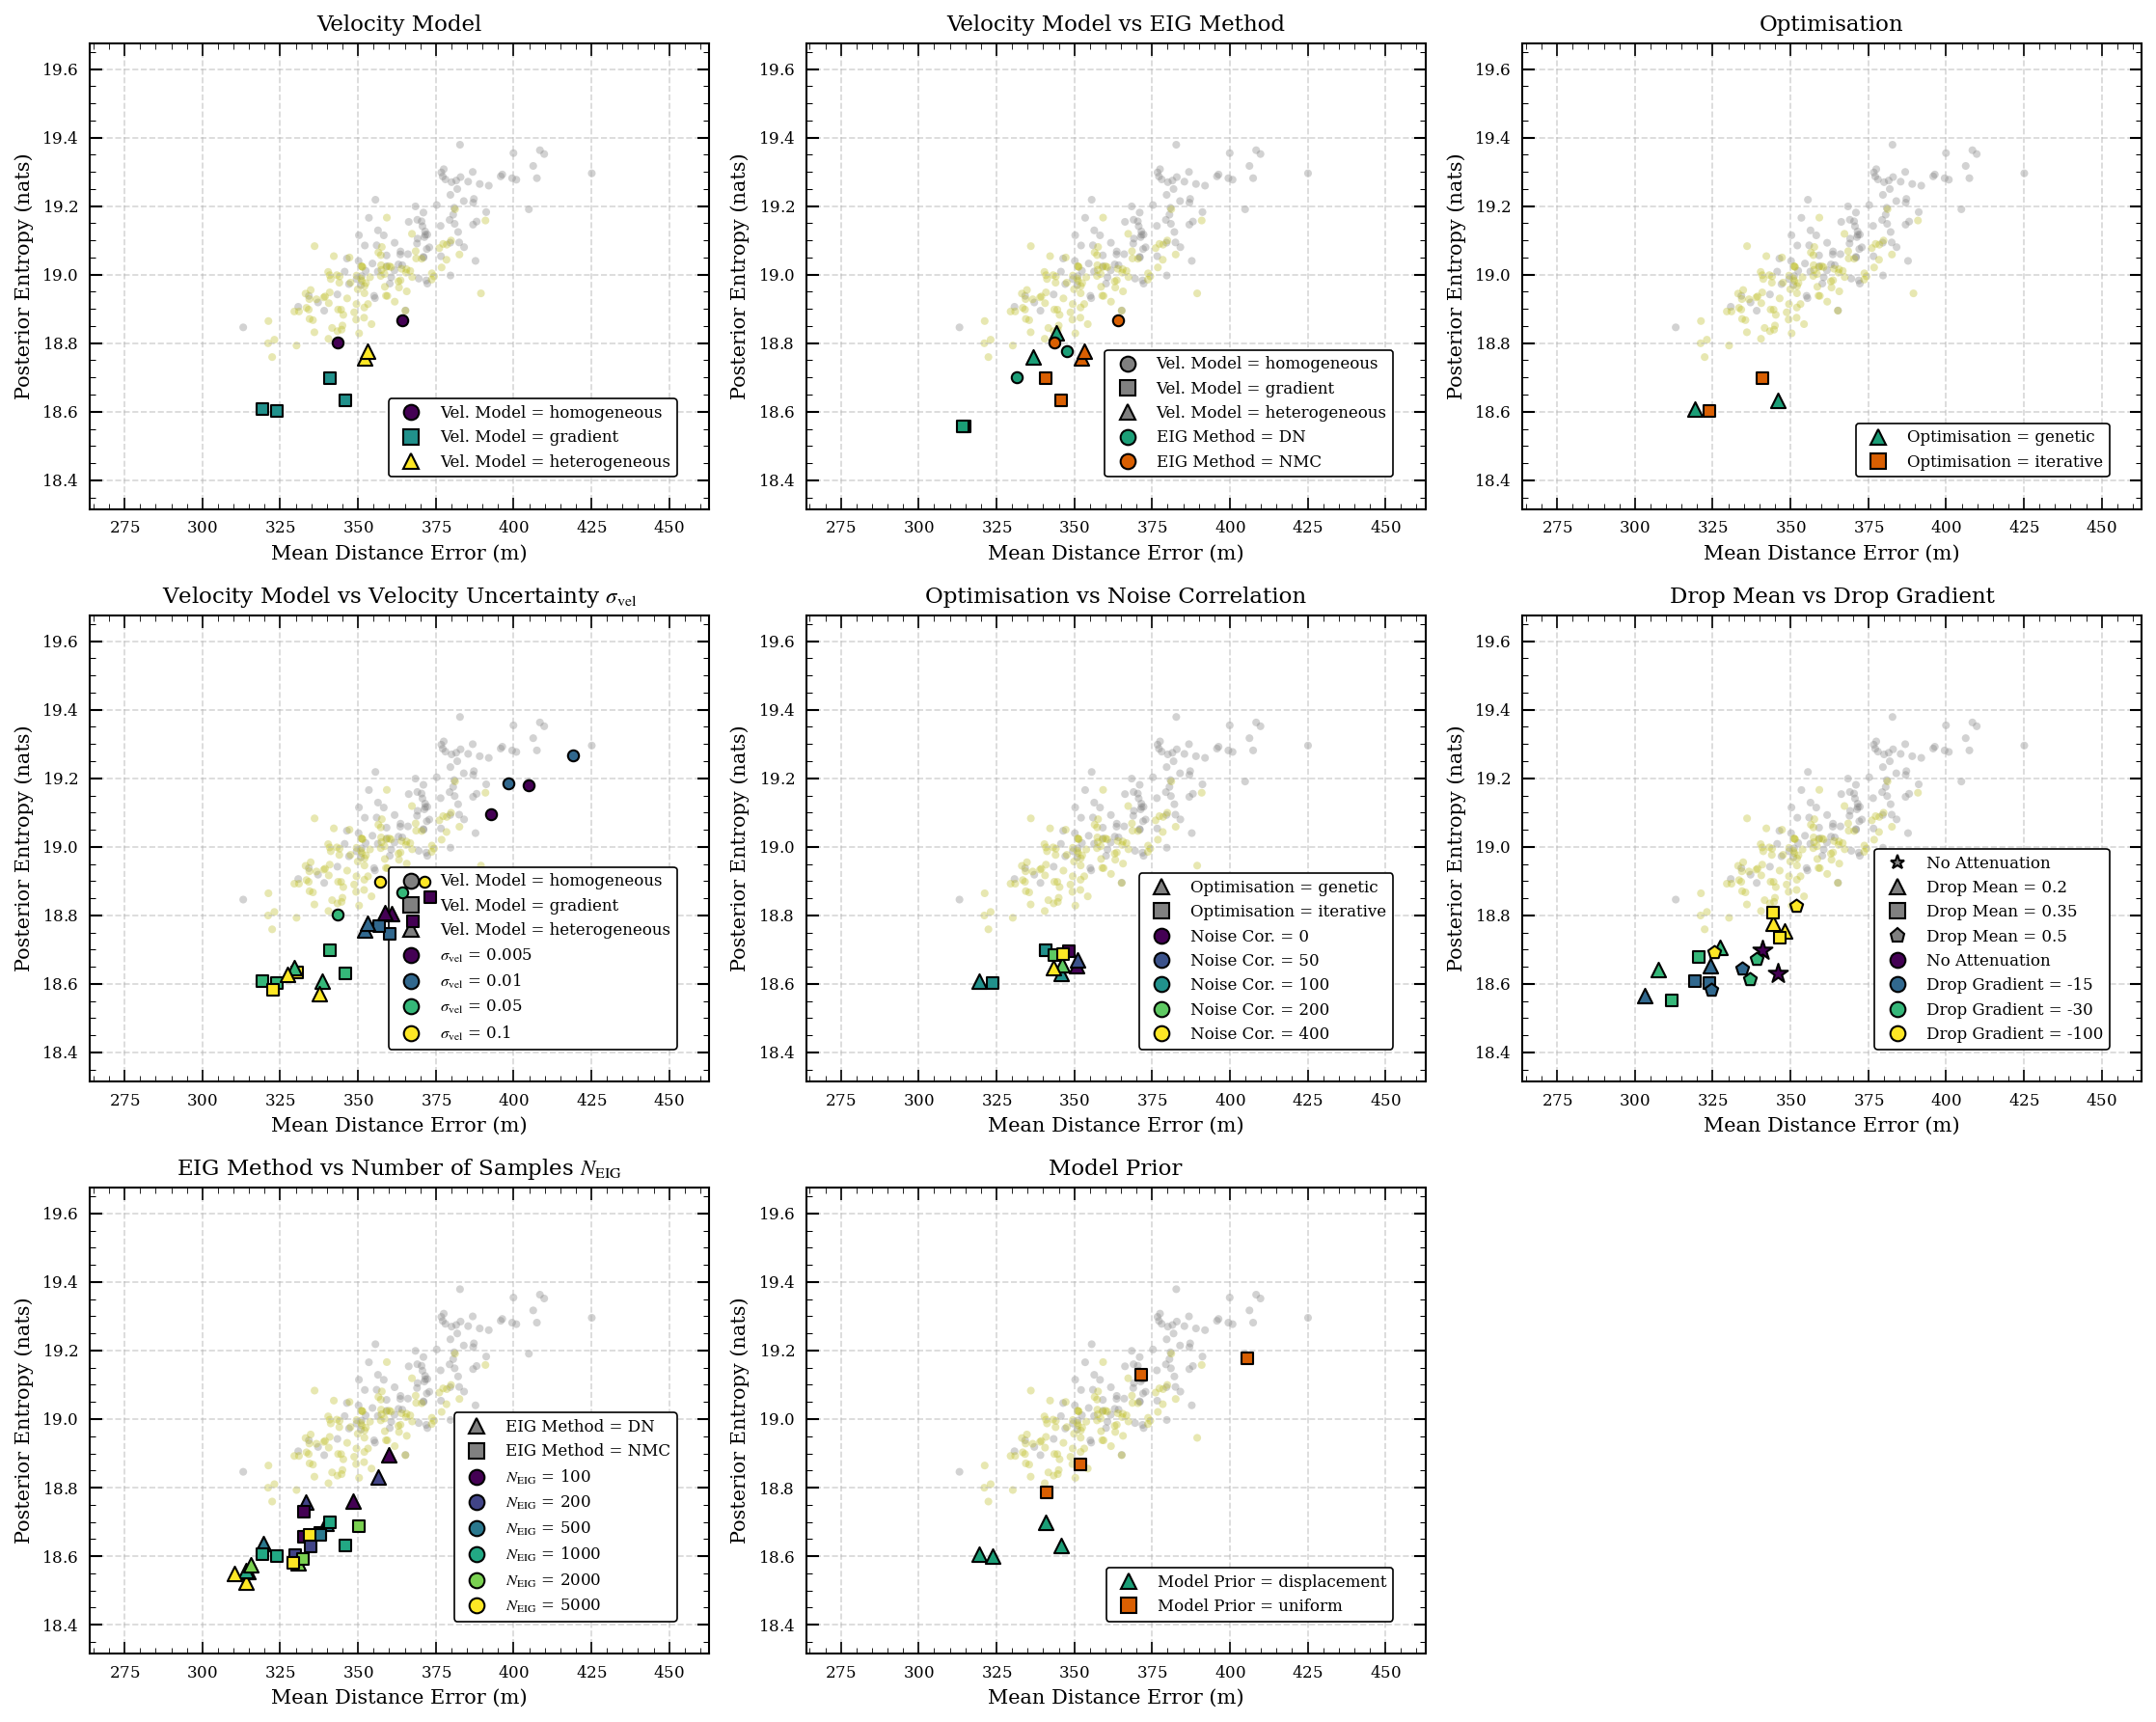

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Define scenario pairs to compare: [param1, param2]
scenarios = {
    ("velocity_model", "velocity_model")   : {'set_defaults': True},
    ("velocity_model", "EIG_method")       : {'set_defaults': True, 'attenuation': False},
    ("optimisation", "optimisation")       : {'set_defaults': True},

    ("velocity_model", "vel_sigma")        : {'set_defaults': True},
    ("optimisation", "noise_correlation")  : {'set_defaults': True},
    ("drop_mean", "drop_gradient")         : {'set_defaults': True},

    ("EIG_method", "EIG_N")                : {'set_defaults': True},
    ("model_prior", "model_prior")         : {'set_defaults': True},
}

def get_color_marker_dicts(param1, param2, values1, values2):
    # Markers for param1, colors for param2
    n1 = len(values1)
    n2 = len(values2)
    # Markers
    if n1 <= 3:
        markers = ["^", "s", "p"]
    elif n1 <= 4:
        markers = ["*", "^", "s", "p"]
    elif n1 <= 6:
        markers = ["^", "s", "p", "*", "P", "X"]
    else:
        markers = ["o"] * n1
    marker_dict = {v: markers[i % len(markers)] for i, v in enumerate(values1)}
    # Colors
    fixed_colors = ['#1b9e77', '#d95f02']
    if n2 <= 2:
        color_dict = {v: fixed_colors[i % len(fixed_colors)] for i, v in enumerate(values2)}
    else:
        cmap = plt.get_cmap("viridis", n2)
        color_dict = {v: cmap(i) for i, v in enumerate(values2)}
    return color_dict, marker_dict

n_scenarios = len(scenarios)
n_cols = 3
n_rows = int(np.ceil(n_scenarios / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
axes = axes.flatten()

for i, (param1, param2) in enumerate(scenarios):
    unique_vals1 = np.sort(stats_all[param1].unique())
    unique_vals2 = np.sort(stats_all[param2].unique())
    if param1 == "velocity_model":
        unique_vals1 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "velocity_model":
        unique_vals2 = np.array(['homogeneous', 'gradient', 'heterogeneous'])
    if param2 == "drop_gradient":
        unique_vals2 = unique_vals2[::-1]
    if len(unique_vals2) < 2 or len(unique_vals1) < 1:
        axes[i].set_visible(False)
        continue
    color_dict, marker_dict = get_color_marker_dicts(param1, param2, unique_vals1, unique_vals2)
    if param1 == "velocity_model":
        marker_dict = {
            'homogeneous': 'o',
            'gradient': 's',
            'heterogeneous': '^',
        }
    plot_combinations(
        axes[i],
        data=stats_all,
        x_quantity=x_quantity,
        y_quantity=y_quantity,
        param1=param1,
        param2=param2,
        color_dict=color_dict,
        marker_dict=marker_dict,
        title=f"{param2}" if param1 == param2 else f"{param1} vs {param2}",
        **scenarios[(param1, param2)],
    )

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
